# Plot RMSE Convergence

Notebook này đọc file `training_loss_log.csv` và vẽ:
- RMSE theo epoch
- RMSE làm mượt (rolling mean)
- Điểm RMSE tốt nhất (best epoch)

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [7]:
# Tu dong tim file loss log moi nhat trong thu muc models
models_dir = Path("models")
patterns = [
    "*_paperstyle_*training_loss_log.csv",
    "*_pca3_scikit_anfis_training_loss_log.csv",
]

loss_logs = []
for p in patterns:
    loss_logs.extend(models_dir.glob(p))
loss_logs = sorted(loss_logs)

if not loss_logs:
    raise FileNotFoundError("Khong tim thay training_loss_log.csv trong models/")

loss_log_path = loss_logs[-1]
print("Using loss log:", loss_log_path)

Using loss log: models\20260618_191650_paperstyle_pca_feature_select_training_loss_log.csv


In [8]:
df = pd.read_csv(loss_log_path)
required_cols = {"epoch", "rmse"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"File log thieu cot bat buoc: {missing}")

df = df.sort_values("epoch").reset_index(drop=True)
window = 10
df["rmse_smooth"] = df["rmse"].rolling(window=window, min_periods=1).mean()

best_idx = df["rmse"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])
best_rmse = float(df.loc[best_idx, "rmse"])

print(f"Best RMSE = {best_rmse:.6f} tai epoch {best_epoch}")
print(f"Final RMSE = {df.iloc[-1]['rmse']:.6f}")

Best RMSE = 0.360826 tai epoch 300
Final RMSE = 0.360826


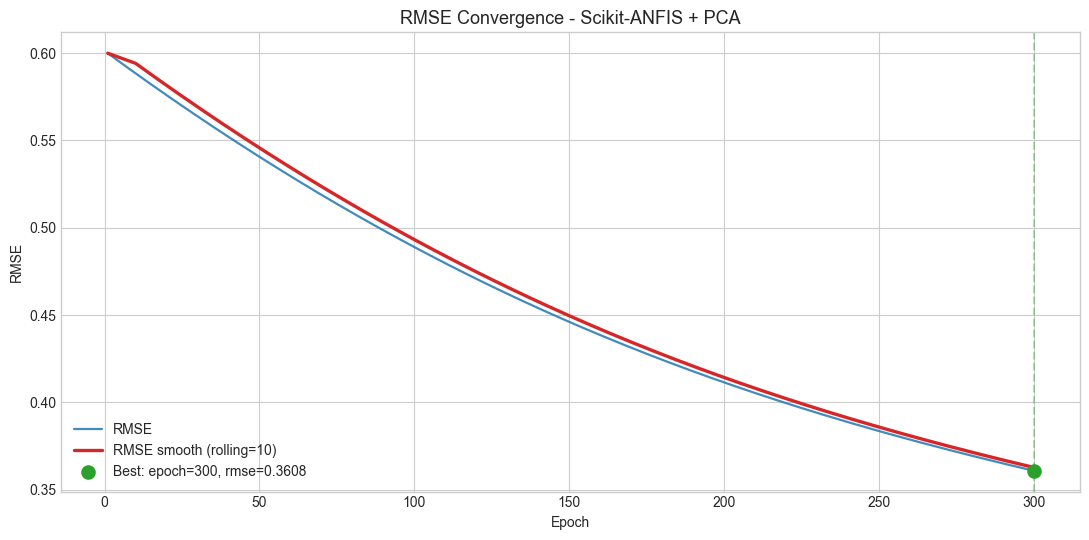

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(df["epoch"], df["rmse"], color="#1f77b4", linewidth=1.6, alpha=0.85, label="RMSE")
ax.plot(df["epoch"], df["rmse_smooth"], color="#d62728", linewidth=2.4, label=f"RMSE smooth (rolling={window})")

ax.scatter([best_epoch], [best_rmse], color="#2ca02c", s=90, zorder=5, label=f"Best: epoch={best_epoch}, rmse={best_rmse:.4f}")
ax.axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.35)

ax.set_title("RMSE Convergence - Scikit-ANFIS + PCA", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [10]:
# (Tuy chon) Luu hinh ra file de chen bao cao
out_png = Path("models") / (loss_log_path.stem.replace("_training_loss_log", "") + "_rmse_convergence.png")
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df["epoch"], df["rmse"], color="#1f77b4", linewidth=1.6, alpha=0.85, label="RMSE")
ax.plot(df["epoch"], df["rmse_smooth"], color="#d62728", linewidth=2.4, label=f"RMSE smooth (rolling={window})")
ax.scatter([best_epoch], [best_rmse], color="#2ca02c", s=90, zorder=5, label=f"Best: epoch={best_epoch}, rmse={best_rmse:.4f}")
ax.axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.35)
ax.set_title("RMSE Convergence - Scikit-ANFIS + PCA", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved plot:", out_png)

Saved plot: models\20260618_191650_paperstyle_pca_feature_select_rmse_convergence.png
